<a href="https://colab.research.google.com/github/andressriosg/Topicos-en-Estadistica/blob/main/rlmpython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files # Para cargar archivos en google colab
uploaded = files.upload()

Saving natalidad (2).csv to natalidad (2).csv


In [ ]:
import pandas as pd
import io
tabla = pd.read_csv(io.BytesIO(uploaded['natalidad (2).csv']), sep = ";", index_col=0, encoding='latin-1')
tabla.head(4)


/tmp/ipykernel_3986/728596684.py:3: DtypeWarning: Columns (4,14,22,28) have mixed types. Specify dtype option on import or set low_memory=False.
  tabla = pd.read_csv(io.BytesIO(uploaded['natalidad (2).csv']), sep = ";", index_col=0, encoding='latin-1')


,areanac,cod_insp,sit_parto,otro_sit,nom_inst,cod_inst,sexo,peso_nac,talla_nac,fecha_nac,...,n_emb,seg_social,idclasadmi,nomclasad,codclasad,edad_padre,niv_edup,ultcurpad,barrio_res,comuna_res
id,,,,,,,,,,,,,,,,,,,,,
1,1,NaN,1,NaN,PROMOTORA MEDICA LAS AMERICAS S.A,5.001021e+10,2,1070,38,23/04/2012,...,4,1,1.0,COOMEVA E.P.S. S.A.,EPS016,42,4,11,El RincÃ³n,16 Belen
2,1,NaN,1,NaN,CLINICA DEL PRADO S.A.,5.001046e+10,2,2900,47,30/05/2012,...,1,1,1.0,SALUD TOTAL S.A. ENTIDAD PROMOTORA DE SALUD,EPS002,25,99,9,Versalles N.2,03 Manrique
3,1,NaN,1,NaN,CLINICA UNIVERSITARIA BOLIVARIANA,5.001034e+10,2,2510,48,04/06/2012,...,2,5,NaN,NaN,NaN,34,8,3,Santa MÃ³nica,12 La America
4,1,NaN,1,NaN,UNIDAD HOSPITALARIA DE MANRRIQUE HERMENEGILDO ...,5.001022e+10,1,3400,50,25/09/2012,...,1,5,NaN,NaN,NaN,24,99,9,Enciso,08 Villa Hermosa


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
sin_atipicos = tabla[(tabla["peso_nac"] < 6000) & (tabla["t_ges"] < 50) & (tabla["edad_madre"] < 99) & (tabla["edad_padre"] < 99)]

In [ ]:
x = sin_atipicos[["t_ges", "edad_madre", "edad_padre"]]
y = sin_atipicos["peso_nac"]

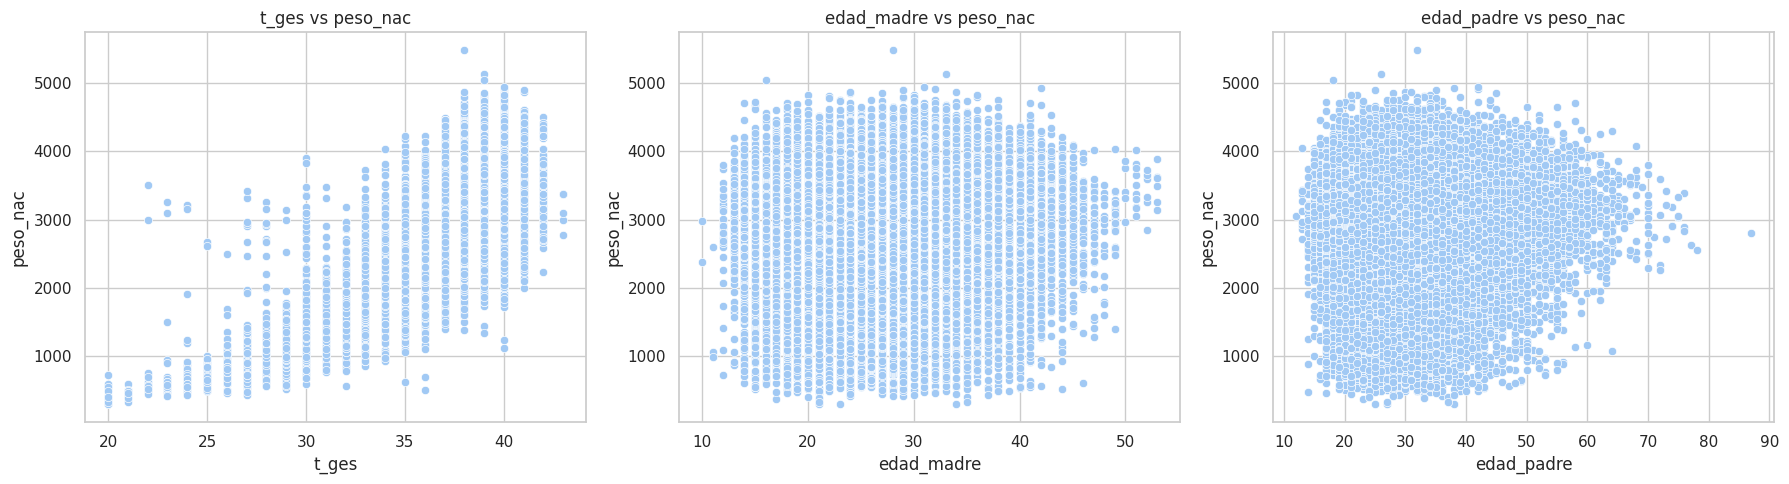

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo bonito
sns.set(style="whitegrid", palette="pastel")

x_vars = ["t_ges", "edad_madre", "edad_padre"]
y = "peso_nac"

# Crear subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(x_vars):
    sns.scatterplot(data=sin_atipicos, x=var, y=y, ax=axes[i])
    axes[i].set_title(f"{var} vs {y}", fontsize=12)

plt.tight_layout()
plt.show()

Se observa mediante los diagramas de dispersión que el peso de un recién nacido depende de su tiempo de gestación. Por otra parte, el peso no depende ni de la edad de la madre ni de la edad del padre.

In [ ]:
import pandas as pd

variables = ["t_ges", "edad_madre", "edad_padre"]
y = "peso_nac"

r2_vals = {}

for var in variables:
    r = sin_atipicos[var].corr(sin_atipicos[y])
    r2_vals[var] = r**2

r2_vals

{'t_ges': np.float64(0.4550732548190663),
 'edad_madre': np.float64(0.0013276201152114468),
 'edad_padre': np.float64(0.0012806119193126107)}

Se considera que el tiempo de gestación si debe considerarse como explicativa porque al no incluirla el coeficiente de determinación es cercano a cero. El resto no es necesario incluirlas porque el coeficiente de determinación no es cercano a cero cuando no están presentes.

In [ ]:
variables = ["t_ges", "edad_madre", "edad_padre"]
y = "peso_nac"

corr_vals = {}

for var in variables:
    r = sin_atipicos[var].corr(sin_atipicos[y])
    corr_vals[var] = r

corr_vals

{'t_ges': np.float64(0.67459117606078),
 'edad_madre': np.float64(0.03643652172218757),
 'edad_padre': np.float64(0.03578563845053782)}

In [ ]:
x = sin_atipicos[["t_ges", "edad_madre", "edad_padre"]]
y = sin_atipicos["peso_nac"]

Se debe considerar la variable tiempo de gestación como explicativa para el peso de nacimiento, porque tiene un coeficiente de correlación mucho mayor que cero. Como para las edades del padre y de la madre estos coeficientes son cercanos a cero, por tanto, se podrían suprimir como variables explicativas.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
trainX, testX, trainY, testY = train_test_split(x, y, test_size = 0.3, random_state=0)
sc=StandardScaler()
scaler = sc.fit(trainX)
trainX_scaled = scaler.transform(trainX)
testX_scaled = scaler.transform(testX)
testX = testX.to_numpy()

In [ ]:
reg = LinearRegression().fit(trainX_scaled, trainY) # entrenamiento

In [ ]:
reg.score(testX_scaled, testY)

0.45914945122828077

In [ ]:
reg.coef_

array([335.04792187,  24.93960027,  11.42787028])

# Validación de supuestos en un modelo de regresión

Puntualmente, en el modelo de regresión lineal múltiple se tienen tres supuestos:
*   Independencia de los residuales: $ɛ_1 , \cdots, ɛ_n$ son independientes  
*   Homocedasticidad  $Var(ɛ_1) = , \cdots = Var (ɛ_n) = \sigma^2$
*   Normalidad: $ɛ_1 , \cdots, ɛ_n, \varepsilon \sim Normal(0, \sigma^2)$



In [ ]:
y_pred = reg.predict(testX_scaled)

# Residuales
residuales = testY - y_pred

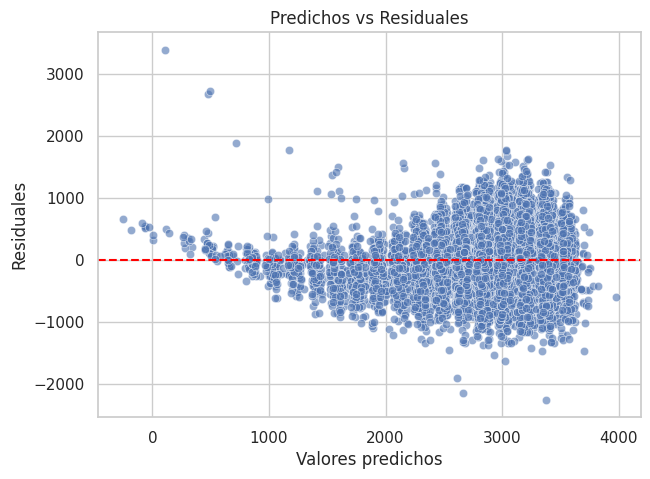

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_pred, y=residuales, alpha=0.6)

# Línea horizontal en 0
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Valores predichos")
plt.ylabel("Residuales")
plt.title("Predichos vs Residuales")

plt.show()

Descriptivamente se observa que sin importar los valores fijos, los residuales son independientes, es decir, se tiene una nube de puntos sin un patrón particular. Esto quiere decir que se puede que los residuales son independientes.  

La mayoría de los residuales están uniformemente distribuidos entre el -2000 y el 2000. Sin embargo, se observa que hay un patrón de ensachamiento en la variabilidad de los residuales, por lo que podemos asumir heterocedasticidad.

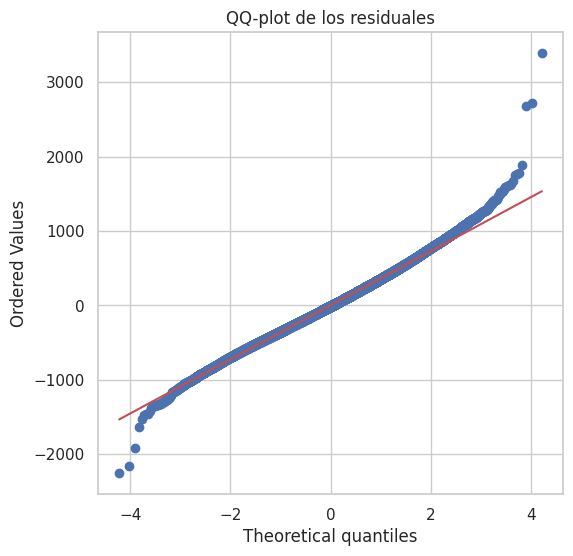

In [ ]:
residuales = testY - y_pred
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(residuales, dist="norm", plot=plt)

plt.title("QQ-plot de los residuales")
plt.show()

No se cumple el supuesto de normalidad de los residuales porque en valores mayores que 2 se observa que muchos están alejados de la recta y = x en el qqplot con respecto a la normal.

Una vez se determina si se cumplen los supuestos o no de forma descriptiva, entonces se procede a ver inferencialmente si se cumplen los supuestos del modelo de regresión lineal múltiple.

In [ ]:
import statsmodels.api as sm
X = sm.add_constant(trainX_scaled)
model = sm.OLS(trainY, X).fit()

In [ ]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
_, p_value, _, _ = acorr_breusch_godfrey(model, nlags=1)
print(p_value)

0.9962221456048774


Con una confianza del 95% no se rechaza que los residuales sean independientes (valor p > 0.05)

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
valorp = het_breuschpagan(model.resid, model.model.exog)[1]
valorp

np.float64(2.2511423706897318e-66)

Con una confianza del 95% se rechaza que los residuales presenten homocedasticidad.

In [ ]:
trainY = trainY.to_numpy()

In [ ]:
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Número de muestras bootstrap
n_samples = 1000
sample_size = 250

p_values = []

for _ in range(n_samples):
    # Índices con reemplazo
    idx = np.random.choice(len(trainY), size=sample_size, replace=True)

    # Submuestra
    X_sample = trainX_scaled[idx]
    y_sample = trainY[idx]

    # Modelo
    X_const = sm.add_constant(X_sample)
    model = sm.OLS(y_sample, X_const).fit()

    # p-value Breusch-Pagan
    p_value = het_breuschpagan(model.resid, model.model.exog)[1]

    p_values.append(p_value)

# Vector de 1000 valores p
p_values = np.array(p_values)

print(p_values)

[6.74008075e-01 3.09185275e-04 8.03527711e-01 3.89998661e-01
 7.88743454e-01 1.89353210e-01 1.38623262e-01 3.34251403e-01
 5.23949002e-01 2.73537209e-01 1.08703029e-04 1.39522740e-01
 8.74283834e-01 8.02300404e-01 2.08887757e-02 8.51201381e-01
 9.68791895e-02 1.79296908e-01 5.38875429e-01 1.34931096e-01
 6.54859506e-01 3.93681553e-01 7.81722350e-01 4.71516520e-01
 8.76353613e-01 3.40568162e-01 5.09377392e-01 3.73185766e-01
 9.42797049e-01 3.86140507e-01 3.62473882e-01 7.41324686e-01
 8.43420086e-01 5.73215540e-01 4.22674523e-01 2.02128319e-01
 8.15665721e-01 8.18608770e-01 2.58181374e-01 6.58438986e-01
 8.72535805e-02 1.21348523e-01 3.20081337e-01 1.41542718e-01
 1.79689780e-01 1.20097110e-01 2.51223678e-01 2.82604251e-01
 8.80920905e-01 8.65575028e-01 5.74397310e-01 1.98686969e-01
 1.65152448e-01 5.26813262e-01 5.33571855e-01 2.80745203e-01
 5.97687712e-03 2.32037111e-01 2.34593458e-01 5.21448027e-01
 4.41290881e-01 4.45213482e-01 7.88698859e-01 7.64138023e-01
 2.83144514e-01 5.027616

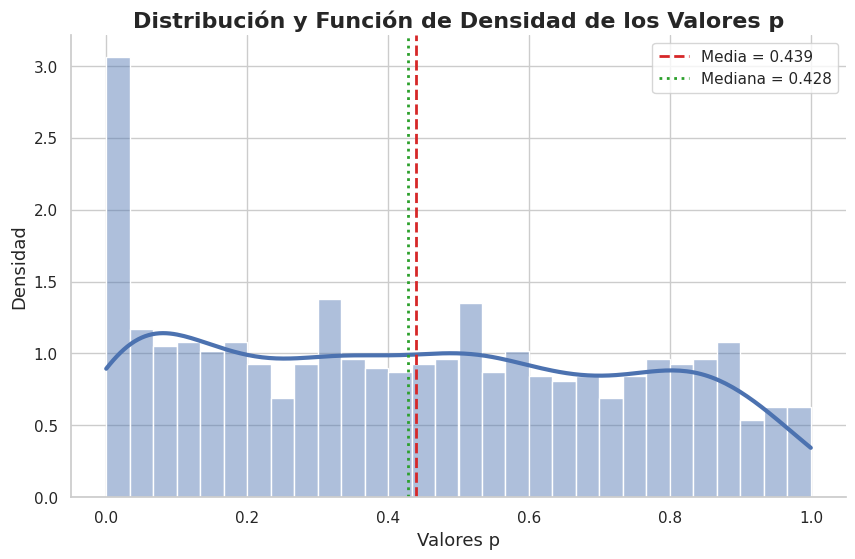

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Asegurar arreglo numpy
p_values = np.array(p_values)

# Estilo elegante
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Histograma normalizado + densidad
sns.histplot(
    p_values,
    bins=30,
    stat="density",
    color="#4C72B0",
    edgecolor="white",
    alpha=0.45,
    kde=True,
    line_kws={"linewidth": 3, "color": "#D62728"}
)

# Líneas de referencia
plt.axvline(
    np.mean(p_values),
    color="#D62728",
    linestyle="--",
    linewidth=2,
    label=f"Media = {np.mean(p_values):.3f}"
)

plt.axvline(
    np.median(p_values),
    color="#2CA02C",
    linestyle=":",
    linewidth=2,
    label=f"Mediana = {np.median(p_values):.3f}"
)

# Títulos y etiquetas
plt.title(
    "Distribución y Función de Densidad de los Valores p",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Valores p", fontsize=13)
plt.ylabel("Densidad", fontsize=13)

# Mejor apariencia
plt.legend(frameon=True)
sns.despine()

plt.show()

De acuerdo con el histograma realizado para los valores p se concluye que no se rechaza (con una confianza del 95%) que los residuales presenten homocedasticidad.

In [ ]:
from scipy.stats import shapiro
stat, p_value = shapiro(model.resid)
print(p_value)

0.03650161201150514


Se rechaza con una confianza del 95% que los residuales presentan distribución normal.

In [ ]:
p_values1 = []

for _ in range(n_samples):
    # Índices con reemplazo
    idx = np.random.choice(len(trainY), size=sample_size, replace=True)

    # Submuestra
    X_sample = trainX_scaled[idx]
    y_sample = trainY[idx]

    # Modelo
    X_const = sm.add_constant(X_sample)
    model = sm.OLS(y_sample, X_const).fit()

    # p-value Breusch-Pagan
    p_value = shapiro(model.resid)[1]

    p_values1.append(p_value)

# Vector de 1000 valores p
p_values1 = np.array(p_values1)

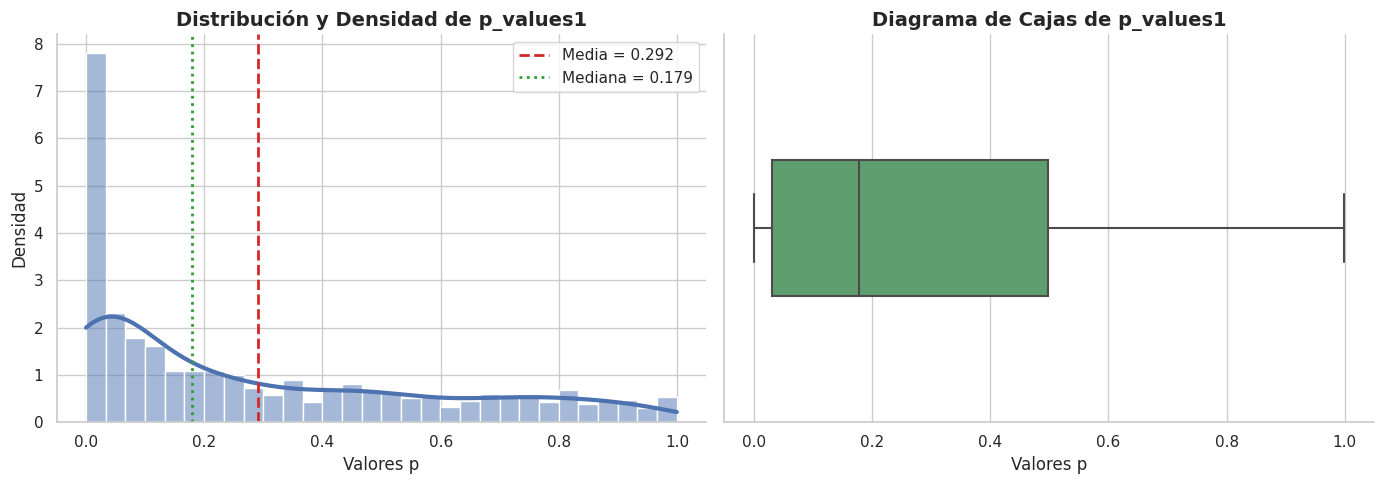

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Asegurar arreglo numpy
p_values1 = np.array(p_values1)

# Estilo visual
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ====================================
# Histograma + función de densidad
# ====================================
sns.histplot(
    p_values1,
    bins=30,
    stat="density",
    kde=True,
    color="#4C72B0",
    edgecolor="white",
    alpha=0.5,
    line_kws={"linewidth": 3, "color": "#D62728"},
    ax=axes[0]
)

axes[0].axvline(
    np.mean(p_values1),
    color="#D62728",
    linestyle="--",
    linewidth=2,
    label=f"Media = {np.mean(p_values1):.3f}"
)

axes[0].axvline(
    np.median(p_values1),
    color="#2CA02C",
    linestyle=":",
    linewidth=2,
    label=f"Mediana = {np.median(p_values1):.3f}"
)

axes[0].set_title(
    "Distribución y Densidad de p_values1",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Valores p")
axes[0].set_ylabel("Densidad")
axes[0].legend()

# ====================================
# Diagrama de cajas
# ====================================
sns.boxplot(
    x=p_values1,
    color="#55A868",
    width=0.35,
    linewidth=1.5,
    fliersize=4,
    ax=axes[1]
)

axes[1].set_title(
    "Diagrama de Cajas de p_values1",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Valores p")

# Ajuste final
sns.despine()
plt.tight_layout()
plt.show()

Al observar el histograma y el diagrama de cajas de los valores p, calculados a partir de 1000 muestras de tamaño 250 de los datos de entrenamiento, usando la prueba de Shapiro, se concluye que no se rechaza la normalidad (con una confianza del 95%).

In [ ]:
x.head(1)

,t_ges,edad_madre,edad_padre
id,,,
1,30,39,42


In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     39.13
Date:                Mon, 11 May 2026   Prob (F-statistic):           1.04e-20
Time:                        22:40:12   Log-Likelihood:                -1826.6
No. Observations:                 250   AIC:                             3661.
Df Residuals:                     246   BIC:                             3675.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3094.3147     23.073    134.110      0.0